In [144]:
import pandas as pd
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 20)
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from scipy.stats import randint, uniform
import joblib
import csv

### Data Preprocessing

In [152]:
df = pd.read_csv("./datasets/new_raw.csv")
first = ["name", "nvar"]
df = df[first + [c for c in df.columns if c not in first]]
df["nvar"].value_counts
df = df.sort_values(["name", "nvar", "mem"]).reset_index()
df

,index,name,nvar,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,dual_feas,status,timed_bytes,timed_time,timed_gctime,nlp_warmup_time,mem,neval_grad,iter,source_solver,problem,neval_obj,timestamp_solver,error_solver,vector_type,extract_duration_problem,highest_degree (ExprTree),nln_nnzj,adbackend_hessian_backend_type,minimize,count_plus_minus,alloc_obj,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,tree_length,count_trigonometric_function,matrix_free,nlin,time_obj,tree_depth,is_constant (ExprTree),nnzj,alloc_hprod,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,count_exponential_function,islp,count_op_function,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,time_grad,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,eval_duration_problem,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,15939,arglina,100,1.0,5.000000e+01,0.319062,0.011306,0.000135,7.841650e-15,first_order,18576.0,0.000164,0.000000,0.377710,1,4.0,1.0,OptimizationProb...,OptimizationProb...,4.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
1,15940,arglina,100,1.0,5.000000e+01,0.319062,0.011309,0.000151,7.841650e-15,first_order,22120.0,0.000199,0.000000,0.377710,2,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModels.Empt...,1.0,NaN,4.261110e+07,0.0,NaN,0.0,5.050000e+03,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,7.712626e+07
2,15941,arglina,100,1.0,5.000000e+01,0.319062,0.011275,0.000140,7.841650e-15,first_order,25592.0,0.000182,0.000000,0.377710,3,2.0,1.0,OptimizationProb...,OptimizationProb...,2.0,2026-02-28 18:33...,NaN,Vector{Float64},4.309682,2.0,0.0,ADNLPModels.Empt...,1.0,305.0,34515160.0,0.0,0.0,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,100.0,100.0,ADNLPModel{Float...,1.0,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,0.0,NaN,ADNLPModels.Forw...,Float64,0.0,0.0,100.0,100.0,10404.0,0.0,1.0,0.0,0.376715,9.0,False,0.0,NaN,ADNLPModels.Empt...,OptimizationProb...,NaN,1.0,0.0,0.0,509.0,NaN,ADNLPModels.Empt...,0.0,0.464686,OptimizationProb...,0.0,1.0,0.0,NaN,0.0,0.0,1.980544,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,0.0,False,0.0,ADNLPModel

### Identity the features and targets for this model

In [154]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "mem",
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "extract_duration_problem",
                    "eval_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "alloc_hprod",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

group_key = ["problem", "name", "nvar"]                                                                                                                   # [...]   
first = list(set(group_key + feature_cols_reg + target_cols_reg  + target_col_model))
df = df[first + [c for c in df.columns if c not in first]]    
df                                                                                       # [1, x41 x42 ... x44]

,count_trigonometric_function,time_obj,eval_duration_problem,mem,neval_grad,highest_degree (ExprTree),timed_bytes,name,nvar,time_grad,count_plus_minus,alloc_hprod,count_op_function,alloc_obj,total_alloc,count_exponential_function,problem,stats_elapsed_time,alloc_grad,tree_length,neval_obj,extract_duration_problem,tree_depth,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type
0,0.0,0.930594,2.515710,1,82.0,2.0,124640.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.089514,2.789270e+08,3992.0,100.0,6.848012,5.0,34.0,8.624897e-10,0.392040,0.100762,0.000109,first_order,0.089571,0.000000,0.229508,34.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,False,OptimizationProb...,False,True,0.0,NaN,False,False,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,False,False,False,ADNLPModels.Empt...,True,NaN,False,NaN,0.0,5.005000e+05,2026-01-31 17:27...,ADNLPModels.Forw...,NaN
1,0.0,0.930594,2.515710,2,17.0,2.0,148496.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.037171,2.789270e+08,3992.0,23.0,6.848012,5.0,12.0,1.763693e-09,0.392040,0.048325,0.000478,first_order,0.037217,0.000000,0.229508,12.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,False,OptimizationProb...,False,True,0.0,NaN,False,False,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,False,False,False,ADNLPModels.Empt...,True,NaN,False,NaN,0.0,5.005000e+05,2026-01-31 17:27...,ADNLPModels.Forw...,NaN
2,0.0,0.930594,2.515710,3,20.0,2.0,181760.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.043753,2.789270e+08,3992.0,26.0,6.848012,5.0,15.0,4.667330e-12,0.392040,0.054916,0.000050,first_order,0.043809,0.000000,0.229508,15.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,False,Optimization

In [155]:
df = df.copy()
df["mem_count"] = df.groupby(["problem", "name", "nvar"]).transform('size')
df = df[df["mem_count"] == 100].copy().reset_index(drop=True)
df

,count_trigonometric_function,time_obj,eval_duration_problem,mem,neval_grad,highest_degree (ExprTree),timed_bytes,name,nvar,time_grad,count_plus_minus,alloc_hprod,count_op_function,alloc_obj,total_alloc,count_exponential_function,problem,stats_elapsed_time,alloc_grad,tree_length,neval_obj,extract_duration_problem,tree_depth,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count
0,0.0,0.930594,2.515710,1,82.0,2.0,124640.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.089514,2.789270e+08,3992.0,100.0,6.848012,5.0,34.0,8.624897e-10,0.392040,0.100762,0.000109,first_order,0.089571,0.000000,0.229508,34.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,False,OptimizationProb...,False,True,0.0,NaN,False,False,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,False,False,False,ADNLPModels.Empt...,True,NaN,False,NaN,0.0,5.005000e+05,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
1,0.0,0.930594,2.515710,2,17.0,2.0,148496.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.037171,2.789270e+08,3992.0,23.0,6.848012,5.0,12.0,1.763693e-09,0.392040,0.048325,0.000478,first_order,0.037217,0.000000,0.229508,12.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,False,OptimizationProb...,False,True,0.0,NaN,False,False,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,False,False,False,ADNLPModels.Empt...,True,NaN,False,NaN,0.0,5.005000e+05,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
2,0.0,0.930594,2.515710,3,20.0,2.0,181760.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.043753,2.789270e+08,3992.0,26.0,6.848012,5.0,15.0,4.667330e-12,0.392040,0.054916,0.000050,first_order,0.043809,0.000000,0.229508,15.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,

In [156]:
# unique instances: one row per (problem, nvar)
instances = df[group_key].drop_duplicates()

# shuffle instances
instances = instances.sample(frac=1, random_state=66).reset_index(drop=True)

n = len(instances)
n_train = int(0.8 * n)

train_inst = instances.iloc[:n_train]
test_inst  = instances.iloc[n_train :]

# assign rows to splits by (problem, nvar)
train_df = df.merge(train_inst, on=["problem", "nvar", "name"], how="inner").reset_index(drop=True)
test_df  = df.merge(test_inst,  on=["problem", "nvar", "name"], how="inner").reset_index(drop=True)
all_df = pd.concat([train_df, test_df], axis=0)
all_df = all_df.reset_index(drop=True)
all_df

,count_trigonometric_function,time_obj,eval_duration_problem,mem,neval_grad,highest_degree (ExprTree),timed_bytes,name,nvar,time_grad,count_plus_minus,alloc_hprod,count_op_function,alloc_obj,total_alloc,count_exponential_function,problem,stats_elapsed_time,alloc_grad,tree_length,neval_obj,extract_duration_problem,tree_depth,nvmops,objective,eval_duration_solver,extract_duration_solver,dual_feas,status,timed_time,timed_gctime,nlp_warmup_time,iter,source_solver,timestamp_solver,error_solver,vector_type,nln_nnzj,adbackend_hessian_backend_type,minimize,jtprod_available,has_equalities,time_hprod,adbackend_jprod_residual_backend_type,adbackend_ghjvprod_backend_type,nnln,jprod_residual_available,nlvb,nlvo,nlp_type,unconstrained,adbackend_jacobian_backend_type,adbackend_jprod_backend_type,hprod_residual_available,jac_available,hess_residual_available,adbackend_gradient_backend_type,float_type,ncon,is_nls,nnzo,nlvc,matrix_free,nlin,is_constant (ExprTree),nnzj,adbackend_jacobian_residual_backend_type,generator,alloc_hess,hess_available,islp,error_problem,adbackend_hprod_residual_backend_type,equality_constrained,source_problem,has_bounds,grad_available,clinvals_nnz,jac_residual_available,bound_constrained,jprod_available,adbackend_hessian_residual_backend_type,nequ,adbackend_jtprod_residual_backend_type,has_inequalities,is_linear (ExprTree),linearly_constrained,adbackend_jtprod_backend_type,hprod_available,jtprod_residual_available,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,mem_count
0,0.0,0.930594,2.515710,1,82.0,2.0,124640.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.089514,2.789270e+08,3992.0,100.0,6.848012,5.0,34.0,8.624897e-10,0.392040,0.100762,0.000109,first_order,0.089571,0.000000,0.229508,34.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,False,OptimizationProb...,False,True,0.0,NaN,False,False,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,False,False,False,ADNLPModels.Empt...,True,NaN,False,NaN,0.0,5.005000e+05,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
1,0.0,0.930594,2.515710,2,17.0,2.0,148496.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.037171,2.789270e+08,3992.0,23.0,6.848012,5.0,12.0,1.763693e-09,0.392040,0.048325,0.000478,first_order,0.037217,0.000000,0.229508,12.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,False,OptimizationProb...,False,True,0.0,NaN,False,False,ADNLPModels.Empt...,NaN,ADNLPModels.Empt...,False,False,False,ADNLPModels.Empt...,True,NaN,False,NaN,0.0,5.005000e+05,2026-01-31 17:27...,ADNLPModels.Forw...,NaN,100
2,0.0,0.930594,2.515710,3,20.0,2.0,181760.0,dqdrtic,1000,0.601327,999.0,NaN,4991.0,444983408.0,7.239104e+08,0.0,OptimizationProb...,0.043753,2.789270e+08,3992.0,26.0,6.848012,5.0,15.0,4.667330e-12,0.392040,0.054916,0.000050,first_order,0.043809,0.000000,0.229508,15.0,OptimizationProb...,2026-02-28 22:33...,NaN,Vector{Float64},0.0,ADNLPModels.Empt...,True,False,False,NaN,ADNLPModels.Empt...,ADNLPModels.Empt...,0.0,NaN,1000.0,1000.0,ADNLPModel{Float...,True,ADNLPModels.Empt...,ADNLPModels.Empt...,NaN,False,NaN,ADNLPModels.Forw...,Float64,0.0,False,1000.0,1000.0,True,0.0,False,0.0,ADNLPModels.Empt...,OptimizationProb...,NaN,True,False,NaN,ADNLPModels.Empt...,

In [157]:
 # confirm and use the three predicted feature to predict time                                                                                                              #  
X_train = train_df[feature_cols_reg].to_numpy(dtype=float)
X_test  = test_df[feature_cols_reg].to_numpy(dtype=float)

y_train = np.log1p(train_df[target_cols_reg].to_numpy(dtype=float))
y_test  = np.log1p(test_df[target_cols_reg].to_numpy(dtype=float))

X_all = np.concatenate([X_train, X_test], axis=0)

### Model selections and hyperparameter tunings of the model

### Best Model: MultiOutputRegressor wrapper with ExtraTreesRegressor (Extremely Randomized Trees)

In [8]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# best_model = MultiOutputRegressor(
#     ExtraTreesRegressor(n_estimators=300, max_depth=10, min_samples_leaf = 5, random_state=123, n_jobs=-1)
#     # TRY random forest 
# )
# best_model.fit(X_train, y_train)
# y_pred = best_model.predict(X_valid)
# print(f"Best model MSE={mean_squared_error(y_valid, y_pred):.4f}  R²={r2_score(y_valid, y_pred):.4f}")

### Random forest 

In [9]:
# param_distributions = {
#     'n_estimators': randint(50, 1500),
#     'max_depth': [None] + list(range(3, 101)),
#     'min_samples_split': randint(2, 100),
#     'min_samples_leaf': randint(1, 50),
#     'max_features': ['sqrt', 'log2'] + list(np.linspace(0.1, 1.0, 19)),
#     'bootstrap': [True, False],
#     'min_impurity_decrease': uniform(0, 0.1),
#     'ccp_alpha': uniform(0, 0.2),
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=50, 
#     cv=10,  
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,  # Use all cores
#     random_state=42,
#     verbose=3,
#     return_train_score=True,
# )

# random_search.fit(X_train, y_train)

# # Results
# print("\n" + "="*80)
# print("BEST RESULTS")
# print("="*80)
# print("Best parameters:", random_search.best_params_)
# print("Best CV score (neg MSE):", random_search.best_score_)
# print("Actual MSE:", -random_search.best_score_)

# # Save detailed results
# results_df = pd.DataFrame(random_search.cv_results_)
# results_df['actual_mse'] = -results_df['mean_test_score']
# results_df = results_df.sort_values('actual_mse')

# # Top 20 configurations
# print("\n" + "="*80)
# print("TOP 20 CONFIGURATIONS")
# print("="*80)
# top_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time', 
#             'param_n_estimators', 'param_max_depth', 'param_max_features',
#             'param_min_samples_split', 'param_min_samples_leaf']
# print(results_df[top_cols].head(20).to_string())

# # Save to CSV
# results_df.to_csv('rf_randomsearch_comprehensive_results.csv', index=False)
# print(f"\nFull results saved to rf_randomsearch_comprehensive_results.csv")

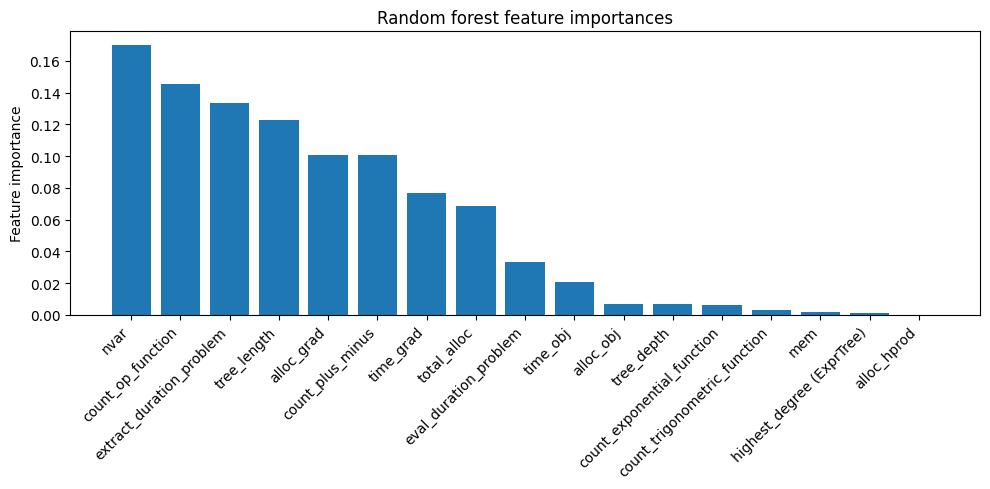

['./model_weights/best_rf_model_reg.pkl']

In [10]:
import numpy as np
import matplotlib.pyplot as plt

best_model = joblib.load('./model_weights/best_rf_model_reg.pkl')
# best_model = random_search.best_estimator_
rf_importances = best_model.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(feature_cols_reg)), [feature_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

joblib.dump(best_model, './model_weights/best_rf_model_reg.pkl')

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, pred)
test_r2  = r2_score(y_test, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test) / np.abs(y_test + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_cols_reg):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error[:, i] < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=2.7952  R²=0.2805

neval_obj:
Relative Error | Under Threshold | Percentage
  <   5%:  3.15%
  <  10%:  10.98%
  <  15%:  23.46%
  <  20%:  31.83%
  <  30%:  53.20%
  <  50%:  92.61%

neval_grad:
Relative Error | Under Threshold | Percentage
  <   5%:  2.80%
  <  10%:  10.20%
  <  15%:  21.63%
  <  20%:  30.88%
  <  30%:  43.59%
  <  50%:  82.32%

timed_bytes:
Relative Error | Under Threshold | Percentage
  <   5%:  48.22%
  <  10%:  85.07%
  <  15%:  92.27%
  <  20%:  97.71%
  <  30%:  99.68%
  <  50%:  100.00%


In [12]:
# import seaborn as sns
# x = df["timed_bytes"]
# sns.histplot(x=x)
# plt.ylim(0, 2000)
# plt.title("Distribution for timed_bytes")
# plt.plot()

### Using the predicted value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [13]:
X_train_time = best_model.predict(X_train)
X_test_time = best_model.predict(X_test)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [14]:
time_predictor = RandomForestRegressor()
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.5445739383578876

In [15]:
# param_distributions = {
#     'n_estimators': randint(50, 1500),
#     'max_depth': [None] + list(range(3, 101)),
#     'min_samples_split': randint(2, 100),
#     'min_samples_leaf': randint(1, 50),
#     'max_features': ['sqrt', 'log2'],
#     'bootstrap': [True, False],
#     'min_impurity_decrease': uniform(0, 0.1),
#     'ccp_alpha': uniform(0, 0.2),
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# time_random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=50,
#     cv=5,  
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,  # Use all cores
#     random_state=42,
#     verbose=3,
#     return_train_score=True,
#     error_score = 'raise'
# )

# time_random_search.fit(X_train_time, y_train_time)


In [16]:
time_best_model = joblib.load('./model_weights/best_rf_model_time.pkl')
accuracy = time_best_model.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model, './model_weights/best_rf_model_time.pkl')

Time prediction accuracy based on predicted values=0.5672626098358102


['./model_weights/best_rf_model_time.pkl']

In [17]:
pred = time_best_model.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=1.7154  R²=0.5673

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  3.29%
  <  10%:  8.07%
  <  15%:  8.49%
  <  20%:  9.73%
  <  30%:  17.22%
  <  50%:  23.27%


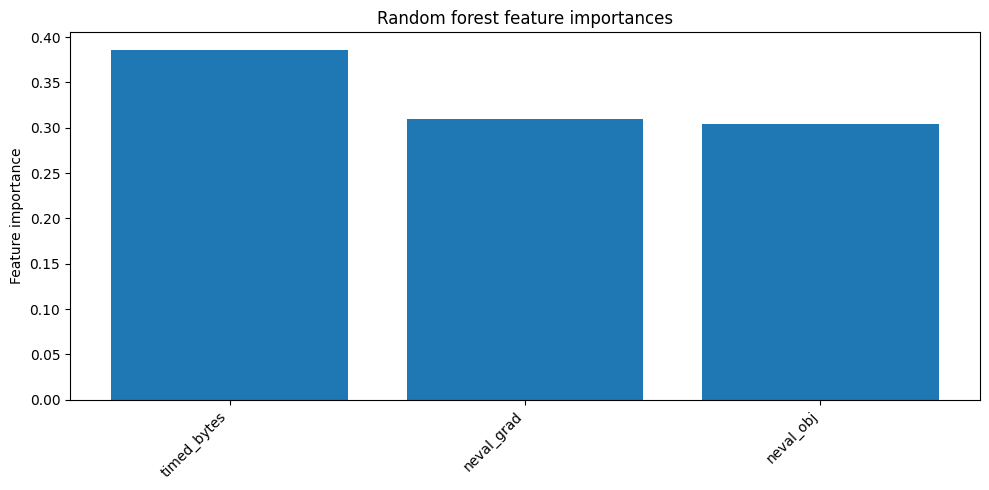

In [18]:
best_model_time = time_best_model
rf_importances = best_model_time.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

plt.figure(figsize=(10, 5))
plt.bar(range(len(target_cols_reg)), rf_importances[indices_rf])
plt.xticks(range(len(target_cols_reg)), [target_cols_reg[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

### Using the actual value of ["neval_obj", "neval_grad", "timed_bytes"] to predict time

In [19]:
X_train_time = pd.concat([
    train_df[target_cols_reg],
    train_df[['mem']]
], axis=1)
X_test_time = pd.concat([
    test_df[target_cols_reg],
    test_df[['mem']]
], axis=1)
y_train_time = np.log1p(train_df[target_col_model].to_numpy(dtype=float)).ravel()
y_test_time = np.log1p(test_df[target_col_model].to_numpy(dtype=float)).ravel()

In [20]:
time_predictor = RandomForestRegressor()
time_predictor.fit(X_train_time, y_train_time)
time_predictor.score(X_test_time, y_test_time)

0.6333713626103623

In [21]:
# param_distributions = {
#     'n_estimators': randint(50, 500),
#     'max_depth': [5, 10, 15, 20, 30, None],
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 10),
#     'max_features': ['sqrt', 'log2', 0.5],
#     'bootstrap': [True],
#     'min_impurity_decrease': uniform(0, 0.01),
#     'criterion': ['squared_error']
# }

# rf = RandomForestRegressor(random_state=42, n_jobs=1)

# time_random_search_raw = RandomizedSearchCV(
#     rf,
#     param_distributions=param_distributions,
#     n_iter=20,
#     cv=3,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     random_state=42,
#     verbose=2,
#     return_train_score=False,
#     error_score='raise'
# )

# time_random_search_raw.fit(X_train_time, y_train_time)

In [22]:
time_best_model_raw = joblib.load('./model_weights/best_rf_model_time_raw.pkl')
# time_best_model_raw = time_random_search_raw.best_estimator_
accuracy = time_best_model_raw.score(X_test_time, y_test_time)
print(f"Time prediction accuracy based on predicted values={accuracy}")

joblib.dump(time_best_model_raw, './model_weights/best_rf_model_time_raw.pkl')

Time prediction accuracy based on predicted values=0.7827759271119532


['./model_weights/best_rf_model_time_raw.pkl']

In [23]:
pred = time_best_model_raw.predict(X_test_time)
test_mse = mean_squared_error(y_test_time, pred)
test_r2  = r2_score(y_test_time, pred)
print(f"MSE={test_mse:.4f}  R²={test_r2:.4f}")

relative_error = np.abs(pred - y_test_time) / np.abs(y_test_time + 1e-8)

#exp((E[Y|xi])

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
for i, col in enumerate(target_col_model):
    print(f"\n{col}:")
    print(f"Relative Error | Under Threshold | Percentage")
    for t in thresholds:
        rate = np.mean(relative_error < t)
        print(f"  <{t:5.0%}:  {rate:.2%}")

MSE=0.8611  R²=0.7828

stats_elapsed_time:
Relative Error | Under Threshold | Percentage
  <   5%:  3.02%
  <  10%:  7.39%
  <  15%:  12.61%
  <  20%:  13.80%
  <  30%:  21.07%
  <  50%:  42.73%


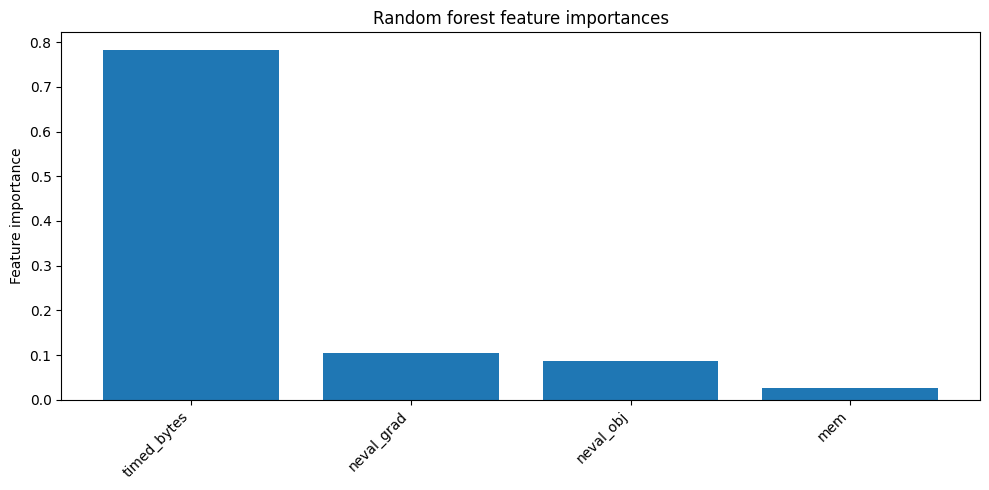

In [24]:
best_model_time_raw = time_best_model_raw
rf_importances = best_model_time_raw.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]  

feature_names_stage2 = target_cols_reg + ['mem']

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names_stage2)), rf_importances[indices_rf])
plt.xticks(range(len(feature_names_stage2)), [feature_names_stage2[i] for i in indices_rf], rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Random forest feature importances")
plt.tight_layout()
plt.show()

### Using linear regression model to predict time based on the ["timed_bytes", "neval_grad", "neval_obj"]

In [25]:
lr = LinearRegression()
lr_model = lr.fit(X_train_time, y_train_time)
accuracy = lr.score(X_test_time, y_test_time)
print(f"Default Linear Regression Model Test Accuracy={accuracy}")

Default Linear Regression Model Test Accuracy=-0.014220469183643614


In [26]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'alpha': np.logspace(-3, 3, 100),
    'positive': [True, False],
    'fit_intercept': [True, False]
}

ridge_search = RandomizedSearchCV(
    Ridge(),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

ridge_search.fit(X_train_time, y_train_time)
print(f"Best params: {ridge_search.best_params_}")
print(f"Best CV R²: {ridge_search.best_score_}")
print(f"Test R²: {ridge_search.score(X_test_time, y_test_time)}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.57937e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.57188e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.58871e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.5728e-18): result may not be accu

Best params: {'positive': True, 'fit_intercept': True, 'alpha': 17.47528400007683}
Best CV R²: -10574.666717485827
Test R²: -0.016707306469555316


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.57937e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.58871e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.5728e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.57188e-18): result may not be accu

### Now let's use stats_ellapsed_time to predict the corresponding best mem value

In [53]:
test_df["predicted_time"] = np.expm1(time_best_model_raw.predict(X_test_time))
test_df["predicted_time"]

0       0.463748
1       0.170962
2       0.170962
3       0.170962
4       0.170962
          ...   
4095    0.441833
4096    0.441833
4097    0.441833
4098    0.464774
4099    0.525624
Name: predicted_time, Length: 4100, dtype: float64

In [54]:
group_cols = ["problem", "name", "nvar"]
best_idx = df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = df.loc[best_idx].set_index(group_cols)["mem"]
df["best_observed_mem"] = df.set_index(group_cols).index.map(best_mem_map)

In [55]:
group_cols = ["problem", "name", "nvar"]
best_idx = test_df.groupby(group_cols)["stats_elapsed_time"].idxmin()
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_observed_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)

In [56]:
group_cols = ["problem", "name", "nvar"]
best_idx = test_df.groupby(group_cols)["predicted_time"].idxmin()
best_mem_map = test_df.loc[best_idx].set_index(group_cols)["mem"]
test_df["best_predicted_mem"] = test_df.set_index(group_cols).index.map(best_mem_map)
test_df["best_predicted_mem"].describe()

count    4100.000000
mean       12.731707
std        14.575433
min         1.000000
25%         3.000000
50%        10.000000
75%        12.000000
max        61.000000
Name: best_predicted_mem, dtype: float64

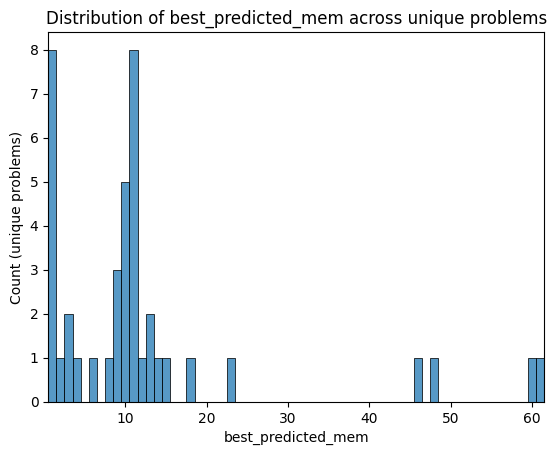

In [57]:
# %pip install seaborn
import seaborn as sns
x = test_df.groupby(['problem', 'name', 'nvar'])['best_predicted_mem'].first()
sns.histplot(x=x, discrete=True)
plt.xlim(0.5, x.max() + 0.5)
plt.xlabel("best_predicted_mem")
plt.ylabel("Count (unique problems)")
plt.title("Distribution of best_predicted_mem across unique problems")
plt.show()

In [60]:
test_df.groupby(['name', 'nvar'])[['best_predicted_mem', 'best_observed_mem', 'predicted_time', 'stats_elapsed_time']].first()

best_predicted_mem  best_observed_mem  predicted_time  \
name         nvar                                                            
arglinb      100                     11                  1        0.463748   
argtrig      100                     60                 61        0.311139   
arwhead      1000                    11                  3        0.474438   
brownal      100                     11                  1        0.246390   
brybnd       10000                   23                  1       46.315576   
clplatea     961                      9                 97        6.913208   
cosine       1000                     1                  1        0.311316   
             100000                   1                  7       60.743887   
cragglvy2    1000                     9                 27        0.306746   
             10000                    9                  3        8.965071   
curly        1000                    13                 36       35.609133   
curly10      1000                    13                 36       35.609133   
dixmaanf     99                      10                 11        0.217289   
dixmaanh     99                      12                 18        0.216438   
dixmaani     99                      46                 96        0.377172   
dixmaanj     999                      1                  1        0.283205   
dixmaanl     9999                     8                 32       24.978792   
dixmaann     99                      61                 99        0.400076   
             999                      3                  1        0.568109   
dixmaano     999                      1                  2        0.296163   
             9999                     2                 87      130.753389   
dqdrtic      10000                    4                  4        6.687529   
dqrtic       1000                    11                  1        0.474438   
fletcbv3_mod 1000                    10                  3        0.210563   
freuroth     1000                    11                  6        0.218038   
genhumps     100                     14                  9        0.814666   
             1000                     1                  2        4.879408   
genrose_nash 1000                     3                  4        6.965300   
noncvxun     1000                    18                 25        6.965300   
nondia       10000                    1                  5        1.996342   
penalty1     100                     11                  2        0.523136   
power        100                     11                  1        0.210563   
             1000                    10                  6        0.213076   
quartc       100                     11                  1        0.474438   
sparsqur     100                     15                  2        0.210328   
spmsrtls     100                     48                 52      268.694593   
srosenbr     1000                    10                  4        0.227233   
tridia       1000                     6                 70        0.591675   
vardim       100                      1                  1        0.213076   
             1000                     1                  6        1.497820   
woods        1000                    10                  8        0.296163   

                     stats_elapsed_time  
name         nvar                        
arglinb      100               0.000229  
argtrig      100               0.013453  
arwhead      1000              0.058931  
brownal      100               0.000280  
brybnd       10000            23.019709  
clplatea     961              16.738348  
cosine       1000              0.049867  
             100000          524.889717  
cragglvy2    1000              0.422347  
             10000            28.180103  
curly        1000            367.790026  
curly10      1000            371.125513  
dixmaanf     99                0.008882  
dixmaanh     99                0.007

Proportions of best_predicted_mem:
best_predicted_mem
1     0.195122
2     0.024390
3     0.048780
4     0.024390
6     0.024390
8     0.024390
9     0.073171
10    0.121951
11    0.195122
12    0.024390
13    0.048780
14    0.024390
15    0.024390
18    0.024390
23    0.024390
46    0.024390
48    0.024390
60    0.024390
61    0.024390
Name: proportion, dtype: float64


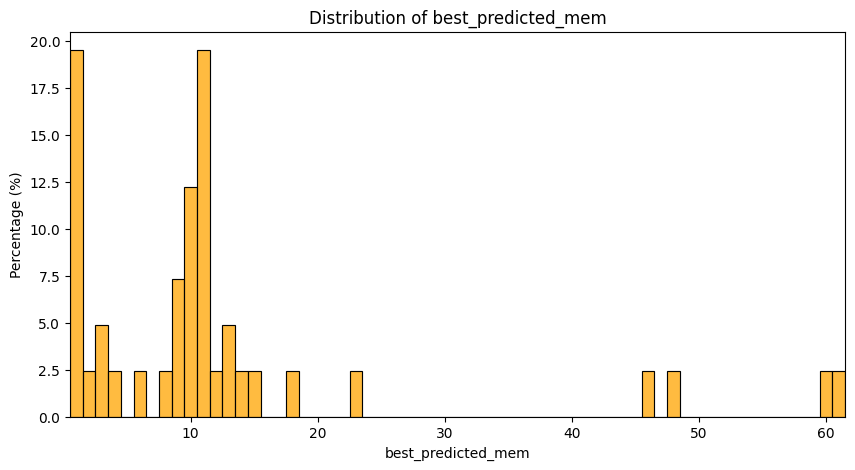

In [32]:
x = test_df["best_predicted_mem"]
proportions = x.value_counts(normalize=True).sort_index()

print("Proportions of best_predicted_mem:")
print(proportions)

plt.figure(figsize=(10, 5))
sns.histplot(x=x, stat='percent', discrete=True, color='orange')
plt.xlabel("best_predicted_mem")
plt.ylabel("Percentage (%)")
plt.title("Distribution of best_predicted_mem")
plt.xlim(0.5, x.max() + 0.5)
plt.show()

### Mem evaluation metrics

In [33]:
# How far off is the predicted mem from actual (in mem units)
mem_absolute_error = abs(test_df['best_predicted_mem'] - test_df['best_observed_mem'])
mame = np.mean(mem_absolute_error)
print(f"Mean Absolute Mem Error: {mame:.2f}")
print(f"Median Absolute Mem Error: {np.median(mem_absolute_error):.2f}")

Mean Absolute Mem Error: 14.37
Median Absolute Mem Error: 6.00


In [34]:
# How close are the predictions? 1.0 = perfect, 0.0 = very far
mem_match_ratio = np.minimum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem']) / \
                  np.maximum(test_df['best_predicted_mem'], 
                              test_df['best_observed_mem'])

mean_match_ratio = np.mean(mem_match_ratio)
print(f"Mean Mem Match Ratio: {mean_match_ratio:.3f}")
# 1.0 = perfect match
# 0.5 = off by 2x (e.g., pred=50, actual=100)
# 0.1 = off by 10x (e.g., pred=10, actual=100)

Mean Mem Match Ratio: 0.442


In [35]:
group_cols = ['problem', 'name', 'nvar']
unique_problems = test_df.groupby(group_cols).first().reset_index()

print(f"Total unique test problems: {len(unique_problems)}\n")

Total unique test problems: 41



In [36]:
print("="*60)
print("MEM PREDICTION ACCURACY")
print("="*60)

exact_match = (unique_problems['best_predicted_mem'] == unique_problems['best_observed_mem']).mean()
print(f"Exact match rate: {exact_match:.1%}")

within_5 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 5).mean()
within_10 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 10).mean()
within_20 = (abs(unique_problems['best_predicted_mem'] - unique_problems['best_observed_mem']) <= 20).mean()

print(f"\nWithin tolerance:")
print(f"  ± 5 mem units:  {within_5:.1%}")
print(f"  ± 10 mem units: {within_10:.1%}")
print(f"  ± 20 mem units: {within_20:.1%}")

MEM PREDICTION ACCURACY
Exact match rate: 9.8%

Within tolerance:
  ± 5 mem units:  41.5%
  ± 10 mem units: 73.2%
  ± 20 mem units: 78.0%


In [37]:
print("="*60)
print("RUNTIME REGRET")
print("="*60)

optimal_times = test_df.groupby(group_cols)['stats_elapsed_time'].min()
predicted_mem_times = test_df.set_index(group_cols + ['mem']).loc[
    [(g[0], g[1], g[2], g[3]) for g in unique_problems[group_cols + ['best_predicted_mem']].itertuples(index=False)]
]['stats_elapsed_time'].values

absolute_regret = predicted_mem_times - optimal_times.values
relative_regret = (absolute_regret / optimal_times.values) * 100

print(f"Mean relative regret: {relative_regret.mean():.2f}%")
print(f"Median relative regret: {np.median(relative_regret):.2f}%")

print(f"\nRegret distribution:")
print(f"  < 5% regret:  {(relative_regret < 5).mean():.1%}")
print(f"  < 10% regret: {(relative_regret < 10).mean():.1%}")
print(f"  < 20% regret: {(relative_regret < 20).mean():.1%}")
print(f"  < 50% regret: {(relative_regret < 50).mean():.1%}")

RUNTIME REGRET
Mean relative regret: 34.72%
Median relative regret: 17.31%

Regret distribution:
  < 5% regret:  22.0%
  < 10% regret: 36.6%
  < 20% regret: 58.5%
  < 50% regret: 78.0%


In [38]:
print("="*60)
print("RANKING QUALITY")
print("="*60)

from scipy.stats import spearmanr

rank_corrs = []
for _, group_data in test_df.groupby(group_cols):
    true_order = group_data.sort_values('mem')['stats_elapsed_time'].values
    pred_order = group_data.sort_values('mem')['predicted_time'].values
    corr, _ = spearmanr(true_order, pred_order)
    rank_corrs.append(corr)

print(f"Mean Spearman correlation: {np.mean(rank_corrs):.3f}")
print(f"Median Spearman correlation: {np.median(rank_corrs):.3f}")

RANKING QUALITY
Mean Spearman correlation: 0.157
Median Spearman correlation: 0.170
